#### Portfolio Optimization: Exact vs. Metaheuristic Approaches

## Optimization Methods – Programming Assignment

**Problem:** Given a universe of N assets with historical returns, select a subset and allocate weights to maximize risk-adjusted return (Sharpe Ratio) subject to real-world constraints (cardinality, min/max position sizes, sector diversification).

**Team Members:** *MS25946444 | MS25946376*

---

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from scipy.optimize import minimize
from itertools import combinations
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [15]:
# !pip install yfinance pandas numpy
# !pip install deap

In [16]:
# ============================================================
# CSE Sri Lanka — Data Collection & Engineering Pipeline (FIXED)
# ============================================================
# pip install yfinance pandas numpy
# ============================================================

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
import time

In [17]:
# ============================================================
# STEP 1: Define CSE Stock Universe
# ============================================================
CSE_STOCKS = {
    # ---- Banking & Finance ----
    'COMB-N0000.CM': {'name': 'Commercial Bank of Ceylon PLC',         'sector': 'Banking & Finance'},
    'HNB-N0000.CM':  {'name': 'Hatton National Bank PLC',              'sector': 'Banking & Finance'},
    'SAMP-N0000.CM': {'name': 'Sampath Bank PLC',                      'sector': 'Banking & Finance'},
    'LOLC-N0000.CM': {'name': 'LOLC Holdings PLC',                     'sector': 'Banking & Finance'},
    'LOFC-N0000.CM': {'name': 'LOLC Finance PLC',                      'sector': 'Banking & Finance'},
    'NTB-N0000.CM':  {'name': 'Nations Trust Bank PLC',                'sector': 'Banking & Finance'},
    'LFIN-N0000.CM': {'name': 'LB Finance PLC',                        'sector': 'Banking & Finance'},
    'DFCC-N0000.CM': {'name': 'DFCC Bank PLC',                         'sector': 'Banking & Finance'},
    'NDB-N0000.CM':  {'name': 'National Development Bank PLC',         'sector': 'Banking & Finance'},
    'SEYB-N0000.CM': {'name': 'Seylan Bank PLC',                       'sector': 'Banking & Finance'},
    'CFIN-N0000.CM': {'name': 'Central Finance Company PLC',           'sector': 'Banking & Finance'},
    'PLC-N0000.CM':  {'name': "People's Leasing & Finance PLC",        'sector': 'Banking & Finance'},
    'COCR-N0000.CM': {'name': 'Commercial Credit and Finance PLC',     'sector': 'Banking & Finance'},
    'PABC-N0000.CM': {'name': 'Pan Asia Banking Corporation PLC',      'sector': 'Banking & Finance'},
    'VFIN-N0000.CM': {'name': 'Vallibel Finance PLC',                  'sector': 'Banking & Finance'},
    'CFVF-N0000.CM': {'name': 'First Capital Holdings PLC',            'sector': 'Banking & Finance'},
    'FCT-N0000.CM':  {'name': 'First Capital Treasuries PLC',          'sector': 'Banking & Finance'},
    'HNBF-N0000.CM': {'name': 'HNB Finance PLC',                       'sector': 'Banking & Finance'},
    'MERC-N0000.CM': {'name': 'Mercantile Investments and Finance PLC', 'sector': 'Banking & Finance'},
    'WLTH-N0000.CM': {'name': 'WealthTrust Securities Limited',        'sector': 'Banking & Finance'},
    'CALT-N0000.CM': {'name': 'Capital Alliance PLC',                  'sector': 'Banking & Finance'},
    'CALH-N0000.CM': {'name': 'Capital Alliance Holdings PLC',         'sector': 'Banking & Finance'},
    'CALF-N0000.CM': {'name': 'Dialog Finance PLC',                    'sector': 'Banking & Finance'},
    'UBC-N0000.CM':  {'name': 'Union Bank of Colombo PLC',             'sector': 'Banking & Finance'},
    'ABL-N0000.CM':  {'name': 'Amana Bank PLC',                        'sector': 'Banking & Finance'},
    'CDB-N0000.CM':  {'name': 'Citizens Development Business Finance PLC', 'sector': 'Banking & Finance'},
    'SFCL-N0000.CM': {'name': 'Senkadagala Finance PLC',               'sector': 'Banking & Finance'},
    'GUAR-N0000.CM': {'name': 'Ceylon Guardian Investment Trust PLC',   'sector': 'Banking & Finance'},
    'SFIN-N0000.CM': {'name': 'Singer Finance (Lanka) PLC',            'sector': 'Banking & Finance'},

    # ---- Diversified ----
    'JKH-N0000.CM':  {'name': 'John Keells Holdings PLC',              'sector': 'Diversified'},
    'MELS-N0000.CM': {'name': 'Melstacorp PLC',                        'sector': 'Diversified'},
    'HAYL-N0000.CM': {'name': 'Hayleys PLC',                           'sector': 'Diversified'},
    'CTHR-N0000.CM': {'name': 'C T Holdings PLC',                      'sector': 'Diversified'},
    'CARS-N0000.CM': {'name': 'Carson Cumberbatch PLC',                'sector': 'Diversified'},
    'VONE-N0000.CM': {'name': 'Vallibel One PLC',                      'sector': 'Diversified'},
    'HHL-N0000.CM':  {'name': 'Hemas Holdings PLC',                    'sector': 'Diversified'},
    'BUKI-N0000.CM': {'name': 'Bukit Darah PLC',                       'sector': 'Diversified'},
    'BIL-N0000.CM':  {'name': 'Browns Investments PLC',                'sector': 'Diversified'},
    'RICH-N0000.CM': {'name': 'Richard Pieris and Company PLC',        'sector': 'Diversified'},
    'SUN-N0000.CM':  {'name': 'Sunshine Holdings PLC',                 'sector': 'Diversified'},
    'SPEN-N0000.CM': {'name': 'Aitken Spence PLC',                     'sector': 'Diversified'},
    'CIC-N0000.CM':  {'name': 'CIC Holdings PLC',                      'sector': 'Diversified'},
    'GREG-N0000.CM': {'name': 'Ambeon Holdings PLC',                   'sector': 'Diversified'},
    'TAP-N0000.CM':  {'name': 'Ambeon Capital PLC',                    'sector': 'Diversified'},
    'BRWN-N0000.CM': {'name': 'Brown and Company PLC',                 'sector': 'Diversified'},
    'EBCR-N0000.CM': {'name': 'E.B. Creasy & Company PLC',             'sector': 'Diversified'},

    # ---- Food & Beverages ----
    'CTC-N0000.CM':  {'name': 'Ceylon Tobacco Company PLC',            'sector': 'Food & Beverages'},
    'DIST-N0000.CM': {'name': 'Distilleries Company of Sri Lanka PLC', 'sector': 'Food & Beverages'},
    'CARG-N0000.CM': {'name': 'Cargills (Ceylon) PLC',                 'sector': 'Food & Beverages'},
    'LION-N0000.CM': {'name': 'Lion Brewery (Ceylon) PLC',             'sector': 'Food & Beverages'},
    'CCS-N0000.CM':  {'name': 'Ceylon Cold Stores PLC',                'sector': 'Food & Beverages'},
    'BREW-N0000.CM': {'name': 'Ceylon Beverage Holdings PLC',          'sector': 'Food & Beverages'},
    'GRAN-N0000.CM': {'name': 'Ceylon Grain Elevators PLC',            'sector': 'Food & Beverages'},
    'LMF-N0000.CM':  {'name': 'Lanka Milk Foods (CWE) PLC',           'sector': 'Food & Beverages'},
    'LAMB-N0000.CM': {'name': 'Kotmale Holdings PLC',                  'sector': 'Food & Beverages'},
    'TAFL-N0000.CM': {'name': 'Three Acre Farms PLC',                  'sector': 'Food & Beverages'},

    # ---- Telecommunications ----
    'DIAL-N0000.CM': {'name': 'Dialog Axiata PLC',                     'sector': 'Telecommunications'},
    'SLTL-N0000.CM': {'name': 'Sri Lanka Telecom PLC',                 'sector': 'Telecommunications'},

    # ---- Manufacturing ----
    'ACL-N0000.CM':  {'name': 'ACL Cables PLC',                        'sector': 'Manufacturing'},
    'RCL-N0000.CM':  {'name': 'Royal Ceramics Lanka PLC',              'sector': 'Manufacturing'},
    'GLAS-N0000.CM': {'name': 'PGP Glass Ceylon PLC',                  'sector': 'Manufacturing'},
    'TKYO-N0000.CM': {'name': 'Tokyo Cement Company (Lanka) PLC',      'sector': 'Manufacturing'},
    'HAYC-N0000.CM': {'name': 'Haycarb PLC',                           'sector': 'Manufacturing'},
    'DIPD-N0000.CM': {'name': 'Dipped Products PLC',                   'sector': 'Manufacturing'},
    'KCAB-N0000.CM': {'name': 'Kelani Cables PLC',                     'sector': 'Manufacturing'},
    'TJL-N0000.CM':  {'name': 'Teejay Lanka PLC',                      'sector': 'Manufacturing'},
    'JAT-N0000.CM':  {'name': 'JAT Holdings PLC',                      'sector': 'Manufacturing'},
    'SIRA-N0000.CM': {'name': 'Sierra Cables PLC',                     'sector': 'Manufacturing'},
    'MGT-N0000.CM':  {'name': 'Hayleys Fabric PLC',                    'sector': 'Manufacturing'},

    # ---- Consumer Goods ----
    'SINS-N0000.CM': {'name': 'Singer (Sri Lanka) PLC',                'sector': 'Consumer Goods'},
    'UML-N0000.CM':  {'name': 'United Motors Lanka PLC',               'sector': 'Consumer Goods'},
    'DIMO-N0000.CM': {'name': 'Diesel & Motor Engineering PLC',        'sector': 'Consumer Goods'},

    # ---- Energy ----
    'LIOC-N0000.CM': {'name': 'Lanka IOC PLC',                         'sector': 'Energy'},
    'WIND-N0000.CM': {'name': 'WindForce PLC',                         'sector': 'Energy'},
    'LLUB-N0000.CM': {'name': 'Chevron Lubricants Lanka PLC',          'sector': 'Energy'},
    'LGL-N0000.CM':  {'name': 'LAUGFS Gas PLC',                        'sector': 'Energy'},
    'VLL-N0000.CM':  {'name': 'Vidullanka PLC',                        'sector': 'Energy'},

    # ---- Insurance ----
    'CINS-N0000.CM': {'name': 'Ceylinco Holdings PLC',                 'sector': 'Insurance'},
    'UAL-N0000.CM':  {'name': 'Union Assurance PLC',                   'sector': 'Insurance'},
    'JINS-N0000.CM': {'name': 'Janashakthi Insurance PLC',             'sector': 'Insurance'},
    'AAIC-N0000.CM': {'name': 'Softlogic Life Insurance PLC',          'sector': 'Insurance'},
    'HASU-N0000.CM': {'name': 'HNB Assurance PLC',                     'sector': 'Insurance'},

    # ---- Construction ----
    'AEL-N0000.CM':  {'name': 'Access Engineering PLC',                'sector': 'Construction'},

    # ---- Real Estate ----
    'OSEA-N0000.CM': {'name': 'Overseas Realty (Ceylon) PLC',           'sector': 'Real Estate'},
    'PLR-N0000.CM':  {'name': 'Prime Lands Residencies PLC',           'sector': 'Real Estate'},
    'RIL-N0000.CM':  {'name': 'R I L Property PLC',                    'sector': 'Real Estate'},
    'CFLB-N0000.CM': {'name': 'The Colombo Fort Land & Building PLC',  'sector': 'Real Estate'},

    # ---- Technology ----
    'PKME-N0000.CM': {'name': 'Digital Mobility Solutions Lanka PLC',  'sector': 'Technology'},

    # ---- Plantations ----
    'WATA-N0000.CM': {'name': 'Watawala Plantations PLC',              'sector': 'Plantations'},
    'NAMU-N0000.CM': {'name': 'Namunukula Plantations PLC',            'sector': 'Plantations'},
    'CTEA-N0000.CM': {'name': 'Dilmah Ceylon Tea Company PLC',         'sector': 'Plantations'},

    # ---- Healthcare ----
    'ASIR-N0000.CM': {'name': 'Asiri Hospital Holdings PLC',           'sector': 'Healthcare'},
    'LHCL-N0000.CM': {'name': 'The Lanka Hospitals Corporation PLC',   'sector': 'Healthcare'},
    'NHL-N0000.CM':  {'name': 'Nawaloka Hospitals PLC',                'sector': 'Healthcare'},

    # ---- Hotels & Travel ----
    'AHUN-N0000.CM': {'name': 'Aitken Spence Hotel Holdings PLC',      'sector': 'Hotels & Travel'},
    'PALM-N0000.CM': {'name': 'Palm Garden Hotels PLC',                'sector': 'Hotels & Travel'},
    'KHL-N0000.CM':  {'name': 'John Keells Hotels PLC',                'sector': 'Hotels & Travel'},
    'AHPL-N0000.CM': {'name': 'Asian Hotels and Properties PLC',       'sector': 'Hotels & Travel'},
    'HUNA-N0000.CM': {'name': 'Hunas Holdings PLC',                    'sector': 'Hotels & Travel'},
    'EDEN-N0000.CM': {'name': 'Eden Hotel Lanka PLC',                  'sector': 'Hotels & Travel'},

    # ---- Services ----
    'DOCK-N0000.CM': {'name': 'Colombo Dockyard PLC',                  'sector': 'Services'},
}

print(f"Defined {len(CSE_STOCKS)} CSE tickers")
print(f"Sectors: {sorted(set(v['sector'] for v in CSE_STOCKS.values()))}\n")


# ============================================================
# STEP 2: Download Historical Prices via yfinance
# ============================================================

START_DATE = '2020-01-01'
END_DATE   = '2025-12-31'

print(f"Downloading prices from {START_DATE} to {END_DATE}...\n")

all_prices = {}
failed_tickers = []

for ticker_yf, info in CSE_STOCKS.items():
    try:
        data = yf.download(ticker_yf, start=START_DATE, end=END_DATE,
                           progress=False, auto_adjust=True)

        if data is None or len(data) < 100:
            failed_tickers.append(ticker_yf)
            n = len(data) if data is not None else 0
            print(f"  ✗ {ticker_yf:20s} — insufficient data ({n} days)")
            continue

        # ---- FIX: Handle both old and new yfinance column formats ----
        # New yfinance (>=0.2.31) returns MultiIndex columns: ('Close', 'TICKER')
        # Old yfinance returns flat columns: 'Close'
        if isinstance(data.columns, pd.MultiIndex):
            close = data['Close'].iloc[:, 0]   # First (only) ticker's Close
        else:
            close = data['Close']

        # Ensure it's a proper Series with DatetimeIndex
        close = close.squeeze()
        if not isinstance(close, pd.Series):
            failed_tickers.append(ticker_yf)
            print(f"  ✗ {ticker_yf:20s} — unexpected data format")
            continue

        all_prices[ticker_yf] = close
        print(f"  ✓ {ticker_yf:20s} — {len(close)} days  ({info['name']})")

    except Exception as e:
        failed_tickers.append(ticker_yf)
        print(f"  ✗ {ticker_yf:20s} — ERROR: {e}")

    time.sleep(0.5)

print(f"\nSuccessfully downloaded: {len(all_prices)} / {len(CSE_STOCKS)}")
if failed_tickers:
    print(f"Failed tickers: {failed_tickers}")
    print("(Verify these on https://finance.yahoo.com — search by company name)\n")

if len(all_prices) < 5:
    raise RuntimeError("Too few tickers downloaded. Check your internet and ticker symbols.")


# ============================================================
# STEP 3: Build Price Matrix & Compute Returns
# ============================================================

price_df = pd.DataFrame(all_prices)
price_df.index = pd.to_datetime(price_df.index)
price_df = price_df.sort_index()

# Drop tickers with >30% missing days
price_df = price_df.dropna(axis=1, thresh=int(0.7 * len(price_df)))
price_df = price_df.ffill().bfill().dropna()

returns_df = price_df.pct_change().dropna()

# Remove extreme outliers (likely data errors): cap at ±50% daily
returns_df = returns_df.clip(-0.5, 0.5)

print(f"Clean price matrix: {price_df.shape[0]} days × {price_df.shape[1]} stocks")
print(f"Returns matrix:     {returns_df.shape[0]} days × {returns_df.shape[1]} stocks")


# ============================================================
# STEP 4: Compute Annualized Statistics
# ============================================================

TRADING_DAYS = 240
SL_RISK_FREE = 0.10

annual_return = returns_df.mean() * TRADING_DAYS
annual_vol    = returns_df.std()  * np.sqrt(TRADING_DAYS)

valid_tickers = returns_df.columns.tolist()


# ============================================================
# STEP 5: Export CSVs
# ============================================================

output_rows = []
for t in valid_tickers:
    info = CSE_STOCKS.get(t, {'name': t, 'sector': 'Unknown'})
    short_name = t.split('-')[0]
    output_rows.append({
        'Ticker': short_name,
        'Ticker_YF': t,
        'Company': info['name'],
        'Sector': info['sector'],
        'Annual_Return_Pct': round(annual_return[t] * 100, 2),
        'Annual_Volatility_Pct': round(annual_vol[t] * 100, 2),
        'Sharpe_Individual': round(
            (annual_return[t] - SL_RISK_FREE) / annual_vol[t], 3
        ) if annual_vol[t] > 0 else 0,
    })

summary_df = pd.DataFrame(output_rows)
summary_df.to_csv('cse_stock_summary.csv', index=False)
print(f"\n✓ Saved cse_stock_summary.csv ({len(summary_df)} stocks)")

short_map = {t: t.split('-')[0] for t in valid_tickers}
returns_export = returns_df.rename(columns=short_map)
returns_export.index.name = 'Date'
returns_export.to_csv('cse_daily_returns.csv')
print(f"✓ Saved cse_daily_returns.csv ({returns_export.shape[0]} days × {returns_export.shape[1]} stocks)")

cov_annual = returns_df.cov() * TRADING_DAYS
cov_export = cov_annual.copy()
cov_export.index   = [t.split('-')[0] for t in cov_export.index]
cov_export.columns = [t.split('-')[0] for t in cov_export.columns]
cov_export.to_csv('cse_covariance_matrix.csv')
print(f"✓ Saved cse_covariance_matrix.csv ({cov_export.shape[0]}×{cov_export.shape[1]})")

print(f"\n{'='*60}")
print(f"DATA COLLECTION COMPLETE")
print(f"{'='*60}")
print(f"\nStocks per sector:")
print(summary_df.groupby('Sector').size().sort_values(ascending=False).to_string())
print(f"\nTop 10 by Sharpe Ratio:")
print(summary_df.nlargest(10, 'Sharpe_Individual')[
    ['Ticker', 'Company', 'Sector', 'Annual_Return_Pct', 'Annual_Volatility_Pct', 'Sharpe_Individual']
].to_string(index=False))

Defined 101 CSE tickers
Sectors: ['Banking & Finance', 'Construction', 'Consumer Goods', 'Diversified', 'Energy', 'Food & Beverages', 'Healthcare', 'Hotels & Travel', 'Insurance', 'Manufacturing', 'Plantations', 'Real Estate', 'Services', 'Technology', 'Telecommunications']


  ✓ COMB-N0000.CM        — 1535 days  (Commercial Bank of Ceylon PLC)
  ✓ HNB-N0000.CM         — 1538 days  (Hatton National Bank PLC)
  ✓ SAMP-N0000.CM        — 1535 days  (Sampath Bank PLC)
  ✓ LOLC-N0000.CM        — 1535 days  (LOLC Holdings PLC)
  ✓ LOFC-N0000.CM        — 1535 days  (LOLC Finance PLC)
  ✓ NTB-N0000.CM         — 1537 days  (Nations Trust Bank PLC)
  ✓ LFIN-N0000.CM        — 1535 days  (LB Finance PLC)
  ✓ DFCC-N0000.CM        — 1537 days  (DFCC Bank PLC)
  ✓ NDB-N0000.CM         — 1535 days  (National Development Bank PLC)
  ✓ SEYB-N0000.CM        — 1536 days  (Seylan Bank PLC)
  ✓ CFIN-N0000.CM        — 1535 days  (Central Finance Company PLC)
  ✓ PLC-N0000.CM         — 1535 days  (People's Le

$FCT-N0000.CM: possibly delisted; no timezone found

1 Failed download:
['FCT-N0000.CM']: possibly delisted; no timezone found


  ✗ FCT-N0000.CM         — insufficient data (0 days)
  ✓ HNBF-N0000.CM        — 1415 days  (HNB Finance PLC)
  ✓ MERC-N0000.CM        — 1559 days  (Mercantile Investments and Finance PLC)


$WLTH-N0000.CM: possibly delisted; no timezone found

1 Failed download:
['WLTH-N0000.CM']: possibly delisted; no timezone found


  ✗ WLTH-N0000.CM        — insufficient data (0 days)


...

  ✗ CALT-N0000.CM        — insufficient data (0 days)


$CALH-N0000.CM: possibly delisted; no timezone found

1 Failed download:
['CALH-N0000.CM']: possibly delisted; no timezone found


  ✗ CALH-N0000.CM        — insufficient data (0 days)
  ✓ CALF-N0000.CM        — 1535 days  (Dialog Finance PLC)
  ✓ UBC-N0000.CM         — 1535 days  (Union Bank of Colombo PLC)
  ✓ ABL-N0000.CM         — 1545 days  (Amana Bank PLC)
  ✓ CDB-N0000.CM         — 1535 days  (Citizens Development Business Finance PLC)
  ✓ SFCL-N0000.CM        — 1535 days  (Senkadagala Finance PLC)
  ✓ GUAR-N0000.CM        — 1536 days  (Ceylon Guardian Investment Trust PLC)
  ✓ SFIN-N0000.CM        — 1535 days  (Singer Finance (Lanka) PLC)
  ✓ JKH-N0000.CM         — 1535 days  (John Keells Holdings PLC)
  ✓ MELS-N0000.CM        — 1536 days  (Melstacorp PLC)
  ✓ HAYL-N0000.CM        — 1535 days  (Hayleys PLC)
  ✓ CTHR-N0000.CM        — 1536 days  (C T Holdings PLC)
  ✓ CARS-N0000.CM        — 1536 days  (Carson Cumberbatch PLC)
  ✓ VONE-N0000.CM        — 1535 days  (Vallibel One PLC)
  ✓ HHL-N0000.CM         — 1538 days  (Hemas Holdings PLC)
  ✓ BUKI-N0000.CM        — 1535 days  (Bukit Darah PLC)
  ✓ BIL-N000

$PKME-N0000.CM: possibly delisted; no timezone found

1 Failed download:
['PKME-N0000.CM']: possibly delisted; no timezone found


  ✗ PKME-N0000.CM        — insufficient data (0 days)
  ✓ WATA-N0000.CM        — 1537 days  (Watawala Plantations PLC)
  ✓ NAMU-N0000.CM        — 1536 days  (Namunukula Plantations PLC)
  ✓ CTEA-N0000.CM        — 1536 days  (Dilmah Ceylon Tea Company PLC)
  ✓ ASIR-N0000.CM        — 1536 days  (Asiri Hospital Holdings PLC)
  ✓ LHCL-N0000.CM        — 1535 days  (The Lanka Hospitals Corporation PLC)
  ✓ NHL-N0000.CM         — 1537 days  (Nawaloka Hospitals PLC)
  ✓ AHUN-N0000.CM        — 1536 days  (Aitken Spence Hotel Holdings PLC)
  ✓ PALM-N0000.CM        — 1536 days  (Palm Garden Hotels PLC)
  ✓ KHL-N0000.CM         — 1535 days  (John Keells Hotels PLC)
  ✓ AHPL-N0000.CM        — 1535 days  (Asian Hotels and Properties PLC)
  ✓ HUNA-N0000.CM        — 1536 days  (Hunas Holdings PLC)
  ✓ EDEN-N0000.CM        — 1536 days  (Eden Hotel Lanka PLC)
  ✓ DOCK-N0000.CM        — 1535 days  (Colombo Dockyard PLC)

Successfully downloaded: 96 / 101
Failed tickers: ['FCT-N0000.CM', 'WLTH-N0000.CM', 

In [18]:
# ============================================================
# 3.1  Load CSE Sri Lanka Real-World Stock Data
# ============================================================
# Pre-requisite: Run collect_cse_data.py first to generate:
#   - cse_stock_summary.csv
#   - cse_daily_returns.csv
# ============================================================

import numpy as np
import pandas as pd

# ---------- PARAMETERS ----------
K_MAX = 8           # Maximum assets in portfolio
W_MIN = 0.03        # Minimum position size (3%)
W_MAX = 0.40        # Maximum position size (40%)
RISK_FREE_RATE = 0.10   # Sri Lanka T-bill rate (~10%)
TRADING_DAYS = 240       # CSE trading days per year

# ---------- LOAD DATA ----------
summary = pd.read_csv('cse_stock_summary.csv')
returns = pd.read_csv('cse_daily_returns.csv', index_col='Date', parse_dates=True)

print(f"Loaded {len(summary)} CSE stocks across {summary['Sector'].nunique()} sectors")
print(f"Daily returns: {returns.shape[0]} trading days\n")

# ---------- BUILD OPTIMIZATION ARRAYS ----------
# Use only tickers that appear in both files
valid_tickers = [t for t in summary['Ticker'] if t in returns.columns]
summary = summary[summary['Ticker'].isin(valid_tickers)].reset_index(drop=True)
returns = returns[valid_tickers]

N = len(valid_tickers)
asset_names   = summary['Ticker'].values
asset_sectors = summary['Sector'].values

# Annualized expected returns from daily returns
mu   = (returns.mean() * TRADING_DAYS).values
vols = (returns.std() * np.sqrt(TRADING_DAYS)).values

# Annualized covariance matrix
cov_matrix = (returns.cov() * TRADING_DAYS).values

# Ensure positive semi-definite
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues = np.maximum(eigenvalues, 1e-8)
cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T

# ---------- SUMMARY ----------
asset_df = pd.DataFrame({
    'Asset': asset_names,
    'Company': summary['Company'].values,
    'Sector': asset_sectors,
    'Expected Return (%)': np.round(mu * 100, 2),
    'Volatility (%)': np.round(vols * 100, 2),
    'Sharpe (Individual)': np.round((mu - RISK_FREE_RATE) / vols, 3)
})

print("=" * 60)
print("CSE PORTFOLIO OPTIMIZATION — REAL DATA LOADED")
print("=" * 60)
print(f"  Asset Universe : {N} stocks across {len(set(asset_sectors))} sectors")
print(f"  Constraints    : K ≤ {K_MAX}, w_min = {W_MIN}, w_max = {W_MAX}")
print(f"  Risk-free rate : {RISK_FREE_RATE*100:.1f}% (Sri Lanka T-bill)")
print(f"  Data period    : {returns.index.min().date()} – {returns.index.max().date()}")
print()
print("Stocks per sector:")
print(asset_df.groupby('Sector').size().sort_values(ascending=False).to_string())
print()
asset_df.sort_values('Sharpe (Individual)', ascending=False)

Loaded 96 CSE stocks across 14 sectors
Daily returns: 1561 trading days

CSE PORTFOLIO OPTIMIZATION — REAL DATA LOADED
  Asset Universe : 96 stocks across 14 sectors
  Constraints    : K ≤ 8, w_min = 0.03, w_max = 0.4
  Risk-free rate : 10.0% (Sri Lanka T-bill)
  Data period    : 2020-01-02 – 2025-12-30

Stocks per sector:
Sector
Banking & Finance     25
Diversified           17
Manufacturing         11
Food & Beverages      10
Hotels & Travel        6
Energy                 5
Insurance              5
Real Estate            4
Healthcare             3
Consumer Goods         3
Plantations            3
Telecommunications     2
Construction           1
Services               1



,Asset,Company,Sector,Expected Return (%),Volatility (%),Sharpe (Individual)
56,GLAS,PGP Glass Ceylon PLC,Manufacturing,53.18,45.70,0.945
15,CFVF,First Capital Holdings PLC,Banking & Finance,53.58,47.66,0.914
27,HAYL,Hayleys PLC,Diversified,50.47,44.76,0.904
38,GREG,Ambeon Holdings PLC,Diversified,51.17,46.02,0.895
48,GRAN,Ceylon Grain Elevators PLC,Food & Beverages,43.03,39.82,0.829
...,...,...,...,...,...,...
19,UBC,Union Bank of Colombo PLC,Banking & Finance,10.38,40.59,0.009
31,HHL,Hemas Holdings PLC,Diversified,8.38,32.62,-0.050
17,MERC,Mercantile Investments and Finance PLC,Banking & Finance,5.34,32.94,-0.141
61,TJL,Teejay Lanka PLC,Manufacturing,5.49,28.24,-0.160


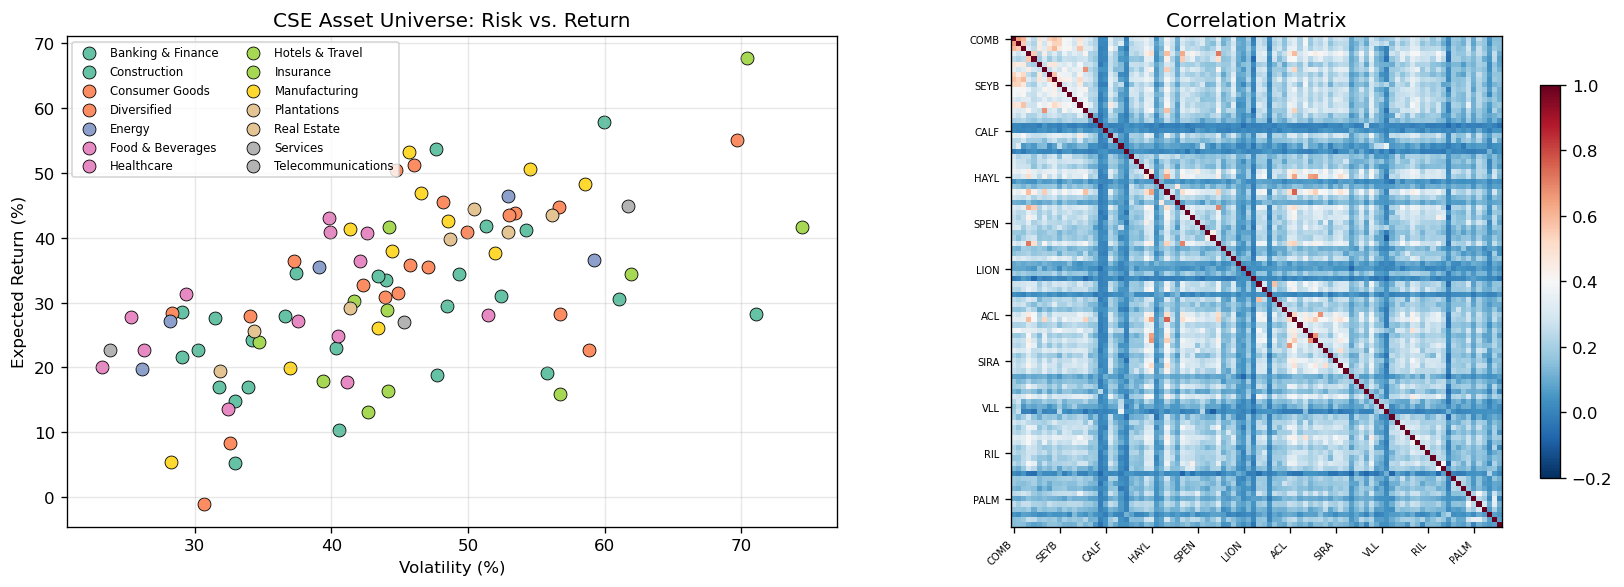

Plotted 96 assets across 14 sectors


In [19]:
# ============================================================
# 3.2 Visualize the Asset Universe (Real CSE Data)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- (a) Risk-Return scatter by sector ---
unique_sectors = sorted(set(asset_sectors))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_sectors)))
sector_colors = {s: colors[i] for i, s in enumerate(unique_sectors)}

ax = axes[0]
for sector in unique_sectors:
    mask = np.array([s == sector for s in asset_sectors])
    ax.scatter(vols[mask] * 100, mu[mask] * 100,
               c=[sector_colors[sector]], label=sector, s=60,
               edgecolors='k', linewidth=0.5)
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Expected Return (%)')
ax.set_title('CSE Asset Universe: Risk vs. Return')
ax.legend(fontsize=7, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

# --- (b) Correlation heatmap ---
# Derive correlation matrix from covariance matrix
std_devs = np.sqrt(np.diag(cov_matrix))
# Avoid division by zero
std_devs[std_devs == 0] = 1e-10
corr_matrix = cov_matrix / np.outer(std_devs, std_devs)

ax = axes[1]
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.2, vmax=1)
ax.set_title('Correlation Matrix')
ax.set_xticks(range(0, N, max(1, N // 10)))
ax.set_yticks(range(0, N, max(1, N // 10)))
ax.set_xticklabels(asset_names[::max(1, N // 10)], rotation=45, ha='right', fontsize=6)
ax.set_yticklabels(asset_names[::max(1, N // 10)], fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('fig_asset_universe.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Plotted {N} assets across {len(unique_sectors)} sectors")

### Helper Functions

In [20]:
# ============================================================
# Core Portfolio Evaluation Functions
# ============================================================

def portfolio_return(weights, mu):
    """Expected portfolio return."""
    return weights @ mu

def portfolio_volatility(weights, cov):
    """Portfolio standard deviation."""
    return np.sqrt(weights @ cov @ weights)

def sharpe_ratio(weights, mu, cov, rf=RISK_FREE_RATE):
    """Sharpe ratio of the portfolio."""
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    if vol < 1e-10:
        return -np.inf
    return (ret - rf) / vol

def optimize_weights_for_subset(subset_indices, mu, cov, w_min=W_MIN, w_max=W_MAX):
    """
    Given a fixed subset of assets, find the weights that maximize the Sharpe ratio.
    This is a continuous optimization problem (no binary variables).
    Uses scipy.optimize.minimize with SLSQP.
    
    Returns: (best_weights_full, sharpe, return, volatility) or None if infeasible.
    """
    k = len(subset_indices)
    if k == 0:
        return None
    
    sub_mu = mu[subset_indices]
    sub_cov = cov[np.ix_(subset_indices, subset_indices)]
    
    # Check feasibility: k * w_min <= 1 and w_max >= 1/k (roughly)
    if k * w_min > 1.0 + 1e-8:
        return None
    
    def neg_sharpe(w):
        ret = w @ sub_mu
        vol = np.sqrt(w @ sub_cov @ w)
        if vol < 1e-10:
            return 1e10
        return -(ret - RISK_FREE_RATE) / vol
    
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bounds = [(w_min, w_max)] * k
    
    # Try multiple starting points for robustness
    best_result = None
    best_sharpe = -np.inf
    
    starting_points = [
        np.ones(k) / k,  # Equal weight
        np.array([w_min]*k)  # Min weight (will be corrected by constraint)
    ]
    # Add a return-proportional start
    if np.sum(sub_mu) > 0:
        prop = np.maximum(sub_mu, 0)
        prop = prop / prop.sum()
        prop = np.clip(prop, w_min, w_max)
        prop = prop / prop.sum()
        starting_points.append(prop)
    
    for w0 in starting_points:
        # Ensure starting point is feasible
        w0 = np.clip(w0, w_min, w_max)
        w0 = w0 / w0.sum()  # Normalize
        
        try:
            result = minimize(neg_sharpe, w0, method='SLSQP',
                            bounds=bounds, constraints=constraints,
                            options={'maxiter': 500, 'ftol': 1e-12})
            if result.success and -result.fun > best_sharpe:
                best_sharpe = -result.fun
                best_result = result
        except:
            continue
    
    if best_result is None:
        return None
    
    w_sub = best_result.x
    
    # Map back to full weight vector
    w_full = np.zeros(len(mu))
    w_full[subset_indices] = w_sub
    
    ret = portfolio_return(w_full, mu)
    vol = portfolio_volatility(w_full, cov)
    sr = (ret - RISK_FREE_RATE) / vol if vol > 1e-10 else -np.inf
    
    return w_full, sr, ret, vol

def format_portfolio(weights, mu, cov, asset_names, asset_sectors):
    """Pretty-print a portfolio solution."""
    selected = np.where(weights > 1e-6)[0]
    ret = portfolio_return(weights, mu)
    vol = portfolio_volatility(weights, cov)
    sr = sharpe_ratio(weights, mu, cov)
    
    print(f"  Sharpe Ratio:      {sr:.4f}")
    print(f"  Expected Return:   {ret*100:.2f}%")
    print(f"  Volatility:        {vol*100:.2f}%")
    print(f"  Assets Selected:   {len(selected)}/{len(weights)}")
    print(f"  Holdings:")
    for i in selected:
        print(f"    {asset_names[i]:8s} ({asset_sectors[i]:12s}): {weights[i]*100:6.2f}%")
    
    # Sector breakdown
    sector_weights = {}
    for i in selected:
        s = asset_sectors[i]
        sector_weights[s] = sector_weights.get(s, 0) + weights[i]
    print(f"  Sector Allocation:")
    for s, w in sorted(sector_weights.items(), key=lambda x: -x[1]):
        print(f"    {s:12s}: {w*100:6.2f}%")

print("Helper functions defined.")

Helper functions defined.


## Method 1: Exact Method — Branch and Bound

### Approach

We implement a Branch and Bound algorithm that explores the space of asset subsets. The key insight is:

1. **Branching:** At each node, decide whether to include or exclude an asset
2. **Bounding:** Compute an upper bound on the Sharpe ratio achievable from any completion of the current partial solution
3. **Pruning:** If the upper bound ≤ best known solution, prune the branch

**Upper Bound Computation:** For a partial selection, we compute the unconstrained (relaxed) optimal Sharpe ratio using all remaining candidate assets plus already-selected ones, ignoring the cardinality constraint. This provides a valid upper bound since removing constraints can only improve the objective.

For moderate N (≤30), this is tractable with good pruning. For larger N, it demonstrates exponential growth — motivating the heuristic.

In [21]:
# ============================================================
# 5.1 Branch and Bound Implementation
# ============================================================

class BranchAndBound:
    """
    Branch and Bound for Cardinality-Constrained Portfolio Optimization.
    Explores subsets of assets (up to K) and finds the one that maximizes
    the Sharpe ratio, with min/max weight constraints.
    """
    
    def __init__(self, mu, cov, k_max, w_min, w_max, rf=RISK_FREE_RATE):
        self.mu = mu
        self.cov = cov
        self.n = len(mu)
        self.k_max = k_max
        self.w_min = w_min
        self.w_max = w_max
        self.rf = rf
        
        # Tracking
        self.best_sharpe = -np.inf
        self.best_weights = None
        self.nodes_explored = 0
        self.nodes_pruned = 0
        self.solutions_evaluated = 0
    
    def upper_bound(self, included, candidates):
        """
        Compute an upper bound on achievable Sharpe ratio.
        Relaxation: use all included + all candidates, ignore cardinality,
        relax min weight to 0. This is a valid upper bound.
        """
        all_indices = list(included) + list(candidates)
        if len(all_indices) == 0:
            return -np.inf
        
        k = len(all_indices)
        sub_mu = self.mu[all_indices]
        sub_cov = self.cov[np.ix_(all_indices, all_indices)]
        
        # Relaxed problem: minimize variance for max return, no cardinality
        def neg_sharpe(w):
            ret = w @ sub_mu
            vol = np.sqrt(np.maximum(w @ sub_cov @ w, 1e-16))
            return -(ret - self.rf) / vol
        
        w0 = np.ones(k) / k
        bounds = [(0, 1)] * k  # Relaxed bounds
        cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}]
        
        try:
            result = minimize(neg_sharpe, w0, method='SLSQP',
                            bounds=bounds, constraints=cons,
                            options={'maxiter': 200, 'ftol': 1e-10})
            if result.success:
                return -result.fun
        except:
            pass
        
        # Fallback: return a loose upper bound
        max_ret = np.max(sub_mu)
        min_vol = np.min(np.sqrt(np.diag(sub_cov)))
        return (max_ret - self.rf) / min_vol if min_vol > 0 else np.inf
    
    def solve(self, time_limit=120):
        """
        Run Branch and Bound. Returns (weights, sharpe, stats_dict).
        """
        self.start_time = time.time()
        self.time_limit = time_limit
        
        # Initial greedy solution for warm start
        individual_sharpes = (self.mu - self.rf) / np.sqrt(np.diag(self.cov))
        top_k = np.argsort(individual_sharpes)[-self.k_max:]
        result = optimize_weights_for_subset(top_k, self.mu, self.cov, self.w_min, self.w_max)
        if result is not None:
            self.best_weights, self.best_sharpe = result[0], result[1]
            self.solutions_evaluated += 1
        
        print(f"  Warm start Sharpe: {self.best_sharpe:.4f}")
        
        # Sort assets by individual Sharpe (best-first branching)
        self.asset_order = np.argsort(individual_sharpes)[::-1]
        
        # Start recursive B&B
        self._branch(included=[], excluded=[], depth=0)
        
        elapsed = time.time() - self.start_time
        stats = {
            'nodes_explored': self.nodes_explored,
            'nodes_pruned': self.nodes_pruned,
            'solutions_evaluated': self.solutions_evaluated,
            'time_seconds': elapsed,
            'optimal_sharpe': self.best_sharpe
        }
        
        return self.best_weights, self.best_sharpe, stats
    
    def _branch(self, included, excluded, depth):
        """Recursive branching."""
        # Time check
        if time.time() - self.start_time > self.time_limit:
            return
        
        self.nodes_explored += 1
        
        # Determine remaining candidates
        decided = set(included) | set(excluded)
        candidates = [self.asset_order[i] for i in range(self.n) 
                      if self.asset_order[i] not in decided]
        
        # If we have a valid subset, evaluate it
        if len(included) >= 2:  # Need at least 2 assets for diversification
            self.solutions_evaluated += 1
            result = optimize_weights_for_subset(
                np.array(included), self.mu, self.cov, self.w_min, self.w_max
            )
            if result is not None and result[1] > self.best_sharpe:
                self.best_sharpe = result[1]
                self.best_weights = result[0]
        
        # Base cases
        if len(candidates) == 0 or len(included) >= self.k_max:
            return
        
        # Pruning: check upper bound
        ub = self.upper_bound(included, candidates)
        if ub <= self.best_sharpe:
            self.nodes_pruned += 1
            return
        
        # Branch on the next candidate (best-first)
        next_asset = candidates[0]
        
        # Branch 1: Include this asset
        self._branch(included + [next_asset], excluded, depth + 1)
        
        # Branch 2: Exclude this asset
        self._branch(included, excluded + [next_asset], depth + 1)

In [22]:
# ============================================================
# 5.2 Run Branch and Bound
# ============================================================

print("="*60)
print("METHOD 1: Branch and Bound (Exact)")
print("="*60)

bb = BranchAndBound(mu, cov_matrix, K_MAX, W_MIN, W_MAX)
bb_weights, bb_sharpe, bb_stats = bb.solve(time_limit=120)

print(f"\n  --- Branch & Bound Results ---")
print(f"  Nodes explored:       {bb_stats['nodes_explored']:,}")
print(f"  Nodes pruned:         {bb_stats['nodes_pruned']:,}")
print(f"  Solutions evaluated:  {bb_stats['solutions_evaluated']:,}")
print(f"  Runtime:              {bb_stats['time_seconds']:.2f}s")
print(f"  Best Sharpe Ratio:    {bb_sharpe:.4f}")
print()
format_portfolio(bb_weights, mu, cov_matrix, asset_names, asset_sectors)

METHOD 1: Branch and Bound (Exact)
  Warm start Sharpe: 1.7352

  --- Branch & Bound Results ---
  Nodes explored:       442
  Nodes pruned:         7
  Solutions evaluated:  441
  Runtime:              120.08s
  Best Sharpe Ratio:    1.8160

  Sharpe Ratio:      1.8160
  Expected Return:   48.66%
  Volatility:        21.29%
  Assets Selected:   8/96
  Holdings:
    CFVF     (Banking & Finance):  14.20%
    SFCL     (Banking & Finance):  13.70%
    HAYL     (Diversified ):   6.97%
    CTHR     (Diversified ):  22.15%
    GREG     (Diversified ):  12.21%
    GRAN     (Food & Beverages):   6.98%
    GLAS     (Manufacturing):  13.98%
    HUNA     (Hotels & Travel):   9.82%
  Sector Allocation:
    Diversified :  41.32%
    Banking & Finance:  27.90%
    Manufacturing:  13.98%
    Hotels & Travel:   9.82%
    Food & Beverages:   6.98%


## Method 2: Genetic Algorithm (Metaheuristic)

### Approach

We implement a Genetic Algorithm (GA) tailored for the cardinality-constrained portfolio problem:

- **Encoding:** Each individual is a binary vector of length N (selected/not selected), combined with continuous weights optimized via SLSQP for each valid subset
- **Fitness:** Sharpe ratio (after weight optimization)
- **Selection:** Tournament selection
- **Crossover:** Uniform crossover on the binary selection vector
- **Mutation:** Flip bits (add/remove assets) with adaptive mutation rate
- **Repair:** Ensure cardinality constraint (≤K assets) by dropping lowest-Sharpe assets

### Why GA?

GAs are well-suited for combinatorial optimization with mixed discrete-continuous variables. The binary selection + continuous weight structure maps naturally to GA encoding. GAs maintain population diversity, reducing risk of premature convergence.

In [23]:
# ============================================================
# 6.1 Genetic Algorithm using DEAP Library
# ============================================================
# Install: pip install deap
# ============================================================

from deap import base, creator, tools, algorithms
import random

# --- DEAP Setup ---
# Fitness: maximize Sharpe Ratio (single objective)
if 'FitnessMax' not in dir(creator):
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if 'Individual' not in dir(creator):
    creator.create("Individual", list, fitness=creator.FitnessMax)


def run_ga_deap(mu, cov, k_max, w_min, w_max, rf=RISK_FREE_RATE,
                pop_size=80, n_generations=150, mutation_rate=0.1,
                crossover_rate=0.85, tournament_size=5):
    """
    Genetic Algorithm for Cardinality-Constrained Portfolio Optimization
    using the DEAP library.

    Encoding: binary chromosome of length N (1 = asset selected, 0 = not)
    Fitness:  Sharpe ratio after continuous weight optimization (SLSQP)

    Returns: (best_weights, best_sharpe, stats_dict)
    """
    n = len(mu)
    random.seed(42)
    np.random.seed(42)

    # ------------------------------------------------------------------
    # Repair: enforce cardinality (≤ k_max) and minimum 2 assets
    # ------------------------------------------------------------------
    def repair(individual):
        selected = [i for i, bit in enumerate(individual) if bit == 1]
        if len(selected) > k_max:
            ind_sharpes = [(i, (mu[i] - rf) / np.sqrt(cov[i, i])) for i in selected]
            ind_sharpes.sort(key=lambda x: x[1], reverse=True)
            keep = set(i for i, _ in ind_sharpes[:k_max])
            for i in range(n):
                individual[i] = 1 if i in keep else 0
        if sum(individual) < 2:
            ind_sharpes = [(i, (mu[i] - rf) / np.sqrt(cov[i, i])) for i in range(n)]
            ind_sharpes.sort(key=lambda x: x[1], reverse=True)
            individual[ind_sharpes[0][0]] = 1
            individual[ind_sharpes[1][0]] = 1
        return individual

    # ------------------------------------------------------------------
    # Evaluate: optimize weights for selected subset → Sharpe ratio
    # ------------------------------------------------------------------
    def evaluate(individual):
        selected = np.array([i for i, bit in enumerate(individual) if bit == 1])
        if len(selected) < 2:
            return (-1e6,)
        result = optimize_weights_for_subset(selected, mu, cov, w_min, w_max)
        if result is None:
            return (-1e6,)
        return (result[1],)   # Return Sharpe as a tuple (DEAP requirement)

    # ------------------------------------------------------------------
    # Random individual: pick 2 to k_max assets
    # ------------------------------------------------------------------
    def random_individual():
        k = random.randint(2, k_max)
        chrom = [0] * n
        for i in random.sample(range(n), k):
            chrom[i] = 1
        return chrom

    # ------------------------------------------------------------------
    # Custom mutation: bit-flip with per-gene probability
    # ------------------------------------------------------------------
    def mutate(individual):
        for i in range(n):
            if random.random() < mutation_rate:
                individual[i] = 1 - individual[i]
        repair(individual)
        return (individual,)

    # ------------------------------------------------------------------
    # DEAP Toolbox Registration
    # ------------------------------------------------------------------
    toolbox = base.Toolbox()
    toolbox.register("individual", tools.initIterate, creator.Individual, random_individual)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", evaluate)
    toolbox.register("select", tools.selTournament, tournsize=tournament_size)
    toolbox.register("mate", tools.cxUniform, indpb=0.5)
    toolbox.register("mutate", mutate)

    # ------------------------------------------------------------------
    # Run the GA using DEAP's eaSimple with elitism via HallOfFame
    # ------------------------------------------------------------------
    start_time = time.time()

    pop = toolbox.population(n=pop_size)
    # Repair initial population
    for ind in pop:
        repair(ind)

    hof = tools.HallOfFame(1)   # Track the single best individual ever
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("best", np.max)
    stats.register("avg", lambda x: np.mean([v for v in x if v > -1e5]))
    stats.register("worst", lambda x: np.min([v for v in x if v > -1e5]))

    pop, logbook = algorithms.eaSimple(
        pop, toolbox,
        cxpb=crossover_rate,
        mutpb=1.0,          # Mutation is handled per-gene inside mutate()
        ngen=n_generations,
        stats=stats,
        halloffame=hof,
        verbose=False        # Set True to see per-generation output
    )

    elapsed = time.time() - start_time

    # ------------------------------------------------------------------
    # Extract best solution
    # ------------------------------------------------------------------
    best_individual = hof[0]
    best_selected = np.array([i for i, bit in enumerate(best_individual) if bit == 1])
    best_result = optimize_weights_for_subset(best_selected, mu, cov, w_min, w_max)

    if best_result is not None:
        best_weights, best_sharpe = best_result[0], best_result[1]
    else:
        best_weights = np.zeros(n)
        best_sharpe = -np.inf

    # Build convergence history from logbook
    convergence = {
        'best':  [record['best']  for record in logbook],
        'avg':   [record['avg']   for record in logbook],
        'worst': [record['worst'] for record in logbook],
    }

    # Print summary
    print(f"  DEAP GA completed: {n_generations} generations, {elapsed:.2f}s")
    print(f"  Best Sharpe: {best_sharpe:.4f}")
    print(f"  Assets selected: {len(best_selected)}")

    ga_stats = {
        'generations': n_generations,
        'population_size': pop_size,
        'total_evaluations': pop_size * (n_generations + 1),
        'time_seconds': elapsed,
        'best_sharpe': best_sharpe,
        'convergence_history': convergence,
    }

    return best_weights, best_sharpe, ga_stats


# ============================================================
# 6.2 Run Genetic Algorithm
# ============================================================

print("=" * 60)
print("METHOD 2: Genetic Algorithm (DEAP Library)")
print("=" * 60)

ga_weights, ga_sharpe, ga_stats = run_ga_deap(
    mu, cov_matrix, K_MAX, W_MIN, W_MAX,
    pop_size=80, n_generations=150,
    mutation_rate=0.08, crossover_rate=0.85,
    tournament_size=5
)

print(f"\n  --- Genetic Algorithm Results ---")
print(f"  Generations:          {ga_stats['generations']}")
print(f"  Total evaluations:    {ga_stats['total_evaluations']:,}")
print(f"  Runtime:              {ga_stats['time_seconds']:.2f}s")
print(f"  Best Sharpe Ratio:    {ga_sharpe:.4f}")
print()
format_portfolio(ga_weights, mu, cov_matrix, asset_names, asset_sectors)

METHOD 2: Genetic Algorithm (DEAP Library)
  DEAP GA completed: 150 generations, 729.19s
  Best Sharpe: 1.9072
  Assets selected: 8

  --- Genetic Algorithm Results ---
  Generations:          150
  Total evaluations:    12,080
  Runtime:              729.19s
  Best Sharpe Ratio:    1.9072

  Sharpe Ratio:      1.9072
  Expected Return:   45.29%
  Volatility:        18.50%
  Assets Selected:   8/96
  Holdings:
    CFVF     (Banking & Finance):  11.97%
    SFCL     (Banking & Finance):  10.70%
    GREG     (Diversified ):  10.99%
    CARG     (Food & Beverages):  21.09%
    LAMB     (Food & Beverages):  12.07%
    GLAS     (Manufacturing):  12.42%
    VLL      (Energy      ):  11.96%
    HUNA     (Hotels & Travel):   8.80%
  Sector Allocation:
    Food & Beverages:  33.16%
    Banking & Finance:  22.66%
    Manufacturing:  12.42%
    Energy      :  11.96%
    Diversified :  10.99%
    Hotels & Travel:   8.80%


##  Comparative Evaluation

In [24]:
# ============================================================
# 7.1 Head-to-Head Comparison Table
# ============================================================

bb_ret = portfolio_return(bb_weights, mu) * 100
bb_vol = portfolio_volatility(bb_weights, cov_matrix) * 100
ga_ret = portfolio_return(ga_weights, mu) * 100
ga_vol = portfolio_volatility(ga_weights, cov_matrix) * 100

comparison = pd.DataFrame({
    'Metric': ['Sharpe Ratio', 'Expected Return (%)', 'Volatility (%)',
               'Assets Selected', 'Runtime (s)', 'Solutions Evaluated'],
    'Branch & Bound': [
        f"{bb_sharpe:.4f}", f"{bb_ret:.2f}", f"{bb_vol:.2f}",
        f"{np.sum(bb_weights > 1e-6)}",
        f"{bb_stats['time_seconds']:.2f}",
        f"{bb_stats['solutions_evaluated']:,}"
    ],
    'Genetic Algorithm': [
        f"{ga_sharpe:.4f}", f"{ga_ret:.2f}", f"{ga_vol:.2f}",
        f"{np.sum(ga_weights > 1e-6)}",
        f"{ga_stats['time_seconds']:.2f}",
        f"{ga_stats['total_evaluations']:,}"
    ]
})

gap = abs(bb_sharpe - ga_sharpe) / max(abs(bb_sharpe), 1e-10) * 100
print("\n" + "="*60)
print("COMPARATIVE EVALUATION")
print("="*60)
print(f"\nOptimality gap (GA vs B&B): {gap:.2f}%\n")
comparison


COMPARATIVE EVALUATION

Optimality gap (GA vs B&B): 5.02%



,Metric,Branch & Bound,Genetic Algorithm
0,Sharpe Ratio,1.8160,1.9072
1,Expected Return (%),48.66,45.29
2,Volatility (%),21.29,18.50
3,Assets Selected,8,8
4,Runtime (s),120.08,729.19
5,Solutions Evaluated,441,"12,080"


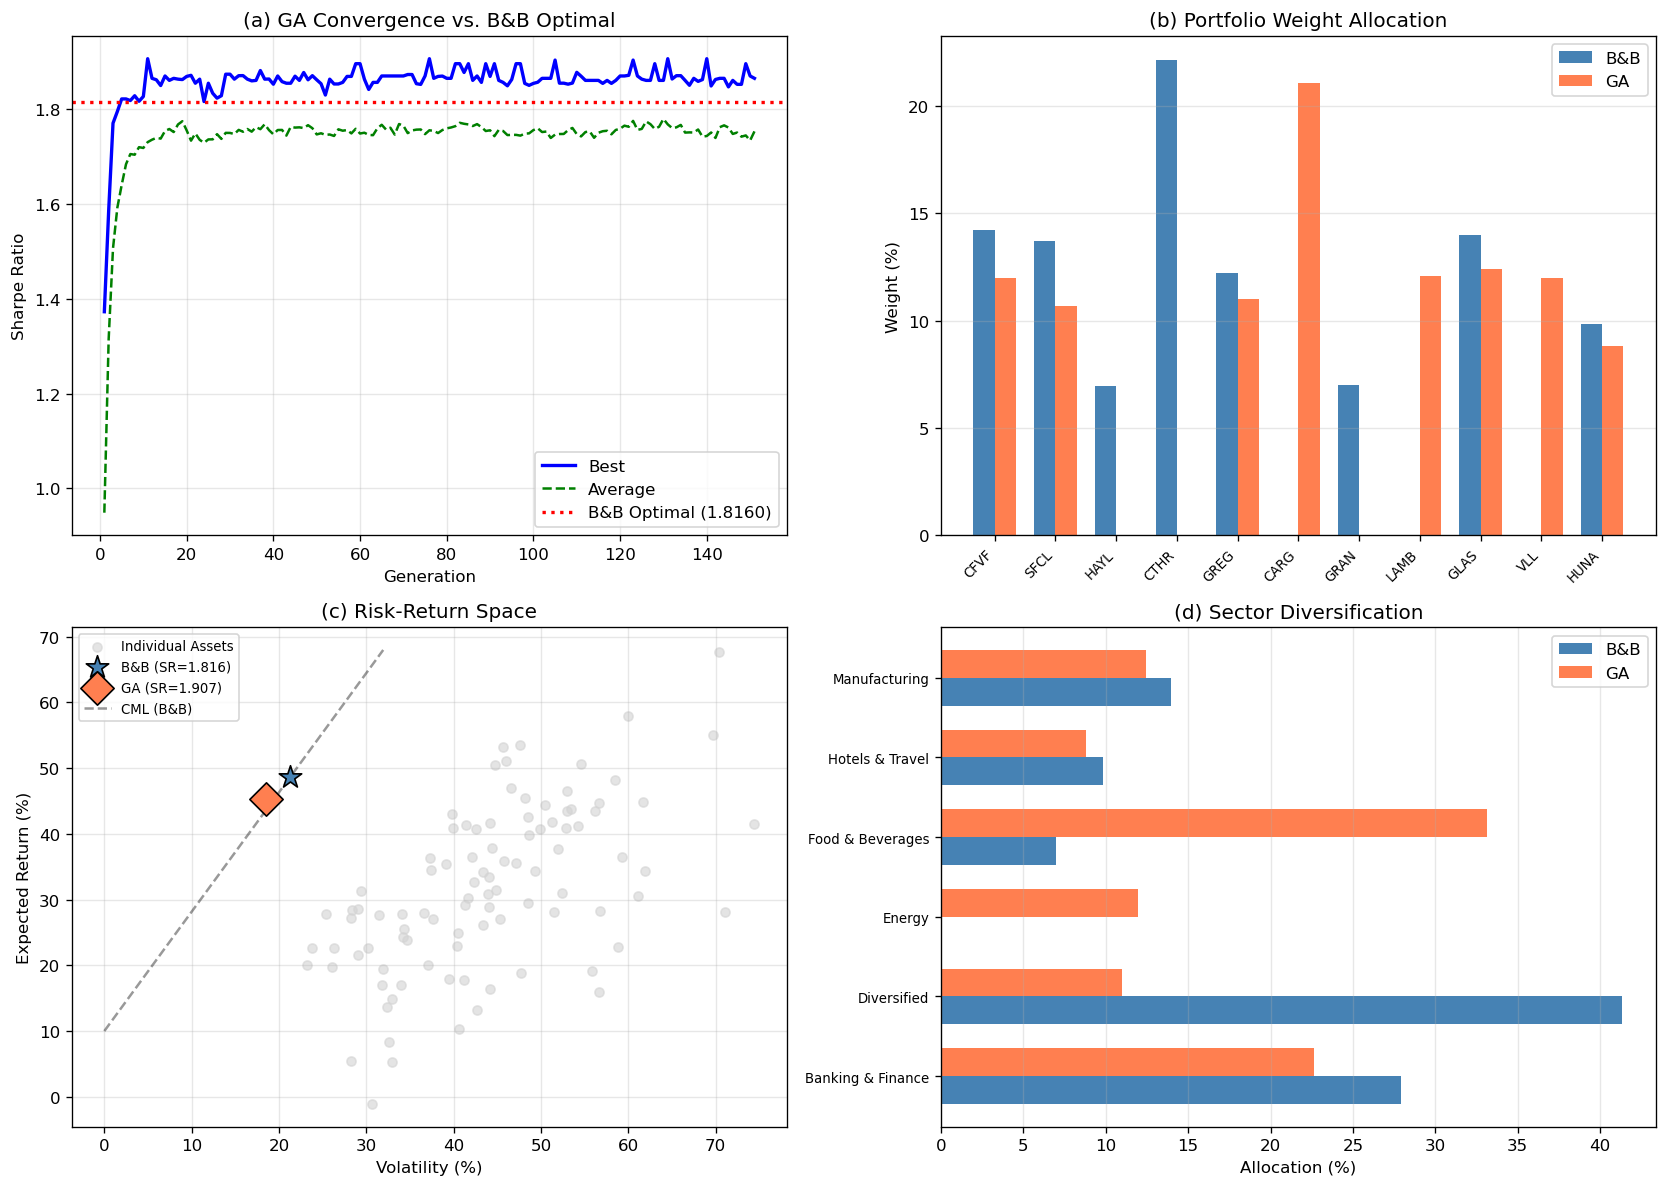

In [25]:
# ============================================================
# 7.2 Visualization: Convergence & Portfolio Comparison
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) GA Convergence
ax = axes[0, 0]
gens = range(1, len(ga_stats['convergence_history']['best']) + 1)
ax.plot(gens, ga_stats['convergence_history']['best'], 'b-', lw=2, label='Best')
ax.plot(gens, ga_stats['convergence_history']['avg'], 'g--', lw=1.5, label='Average')
ax.axhline(y=bb_sharpe, color='r', linestyle=':', lw=2, label=f'B&B Optimal ({bb_sharpe:.4f})')
ax.set_xlabel('Generation')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('(a) GA Convergence vs. B&B Optimal')
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Portfolio weights comparison
ax = axes[0, 1]
bb_selected = np.where(bb_weights > 1e-6)[0]
ga_selected = np.where(ga_weights > 1e-6)[0]
all_selected = sorted(set(list(bb_selected) + list(ga_selected)))
x = np.arange(len(all_selected))
width = 0.35
ax.bar(x - width/2, [bb_weights[i]*100 for i in all_selected], width, label='B&B', color='steelblue')
ax.bar(x + width/2, [ga_weights[i]*100 for i in all_selected], width, label='GA', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([asset_names[i] for i in all_selected], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Weight (%)')
ax.set_title('(b) Portfolio Weight Allocation')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (c) Risk-Return plot
ax = axes[1, 0]
ax.scatter(vols*100, mu*100, c='lightgray', s=30, alpha=0.6, label='Individual Assets')
ax.scatter(bb_vol, bb_ret, c='steelblue', s=200, marker='*', zorder=5,
           label=f'B&B (SR={bb_sharpe:.3f})', edgecolors='k')
ax.scatter(ga_vol, ga_ret, c='coral', s=200, marker='D', zorder=5,
           label=f'GA (SR={ga_sharpe:.3f})', edgecolors='k')
max_vol = max(bb_vol, ga_vol) * 1.5
cml_vols = np.linspace(0, max_vol, 100)
cml_rets = RISK_FREE_RATE*100 + bb_sharpe * cml_vols
ax.plot(cml_vols, cml_rets, 'k--', alpha=0.4, label='CML (B&B)')
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Expected Return (%)')
ax.set_title('(c) Risk-Return Space')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# (d) Sector allocation comparison
ax = axes[1, 1]
# FIX: asset_sectors is a numpy array, not a dict — use sorted(set(...))
all_sectors_list = sorted(set(asset_sectors))
bb_sector_w = [sum(bb_weights[j] for j in range(N) if asset_sectors[j] == s) * 100
               for s in all_sectors_list]
ga_sector_w = [sum(ga_weights[j] for j in range(N) if asset_sectors[j] == s) * 100
               for s in all_sectors_list]

# Only show sectors that have non-zero allocation in at least one portfolio
nonzero = [i for i in range(len(all_sectors_list))
           if bb_sector_w[i] > 0.01 or ga_sector_w[i] > 0.01]
plot_sectors = [all_sectors_list[i] for i in nonzero]
plot_bb = [bb_sector_w[i] for i in nonzero]
plot_ga = [ga_sector_w[i] for i in nonzero]

x = np.arange(len(plot_sectors))
ax.barh(x - width/2, plot_bb, width, label='B&B', color='steelblue')
ax.barh(x + width/2, plot_ga, width, label='GA', color='coral')
ax.set_yticks(x)
ax.set_yticklabels(plot_sectors, fontsize=8)
ax.set_xlabel('Allocation (%)')
ax.set_title('(d) Sector Diversification')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Scalability Analysis

We test both methods on increasing problem sizes to demonstrate the exponential growth of the exact method versus the polynomial behavior of the metaheuristic.

In [28]:
# ============================================================
# 8. Scalability Experiment
# ============================================================

def generate_random_instance(n_assets, seed=None):
    """Generate a random portfolio optimization instance of given size."""
    if seed is not None:
        np.random.seed(seed)
    mu_inst = np.random.uniform(0.03, 0.20, n_assets)
    vols_inst = np.random.uniform(0.10, 0.35, n_assets)
    # Random correlation matrix
    A = np.random.randn(n_assets, n_assets) * 0.3
    corr = A @ A.T
    d = np.sqrt(np.diag(corr))
    corr = corr / np.outer(d, d)
    np.fill_diagonal(corr, 1.0)
    cov_inst = np.outer(vols_inst, vols_inst) * corr
    # Ensure PSD
    eigvals, eigvecs = np.linalg.eigh(cov_inst)
    eigvals = np.maximum(eigvals, 1e-8)
    cov_inst = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return mu_inst, cov_inst

# Test sizes (keep B&B sizes small due to exponential scaling)
test_sizes = [10, 15, 20, 25, 30]
k_test = 5

scalability_results = []

for n in test_sizes:
    print(f"\nTesting N={n}...")
    mu_test, cov_test = generate_random_instance(n, seed=100+n)
    
    # B&B (with time limit)
    bb_test = BranchAndBound(mu_test, cov_test, k_test, W_MIN, W_MAX)
    _, bb_sr, bb_st = bb_test.solve(time_limit=30)
    
    # GA (fixed budget)
    # ga_test = run_ga_deap(
    ga_weights, ga_sr, ga_st = run_ga_deap(
        mu_test, cov_test, k_test, W_MIN, W_MAX,
        pop_size=50, n_generations=60, mutation_rate=0.1
    )
    # _, ga_sr, ga_st = ga_test.solve()
    
    scalability_results.append({
        'N': n,
        'BB_time': bb_st['time_seconds'],
        'BB_sharpe': bb_sr,
        'BB_nodes': bb_st['nodes_explored'],
        'GA_time': ga_st['time_seconds'],
        'GA_sharpe': ga_sr,
        'GA_evals': ga_st['total_evaluations'],
        'Gap_%': abs(bb_sr - ga_sr) / max(abs(bb_sr), 1e-10) * 100
    })

scale_df = pd.DataFrame(scalability_results)
print("\n" + "="*60)
print("SCALABILITY RESULTS")
print("="*60)
scale_df


Testing N=10...
  Warm start Sharpe: 1.4413
  DEAP GA completed: 60 generations, 75.78s
  Best Sharpe: 2.4659
  Assets selected: 5

Testing N=15...
  Warm start Sharpe: 0.8140
  DEAP GA completed: 60 generations, 63.27s
  Best Sharpe: 1.0206
  Assets selected: 5

Testing N=20...
  Warm start Sharpe: 1.2334
  DEAP GA completed: 60 generations, 64.93s
  Best Sharpe: 1.7144
  Assets selected: 5

Testing N=25...
  Warm start Sharpe: 1.1872
  DEAP GA completed: 60 generations, 75.38s
  Best Sharpe: 1.2089
  Assets selected: 5

Testing N=30...
  Warm start Sharpe: 1.8125
  DEAP GA completed: 60 generations, 70.65s
  Best Sharpe: 2.4512
  Assets selected: 5

SCALABILITY RESULTS


,N,BB_time,BB_sharpe,BB_nodes,GA_time,GA_sharpe,GA_evals,Gap_%
0,10,1.858165,2.465944,67,75.780022,2.465944,3050,5.402668e-14
1,15,2.685991,1.020552,79,63.269783,1.020552,3050,2.175729e-13
2,20,6.111447,1.714377,169,64.930849,1.714377,3050,2.590382e-14
3,25,3.527958,1.208852,71,75.379523,1.208852,3050,0.000000e+00
4,30,30.044994,2.451214,567,70.652232,2.451214,3050,1.811711e-14


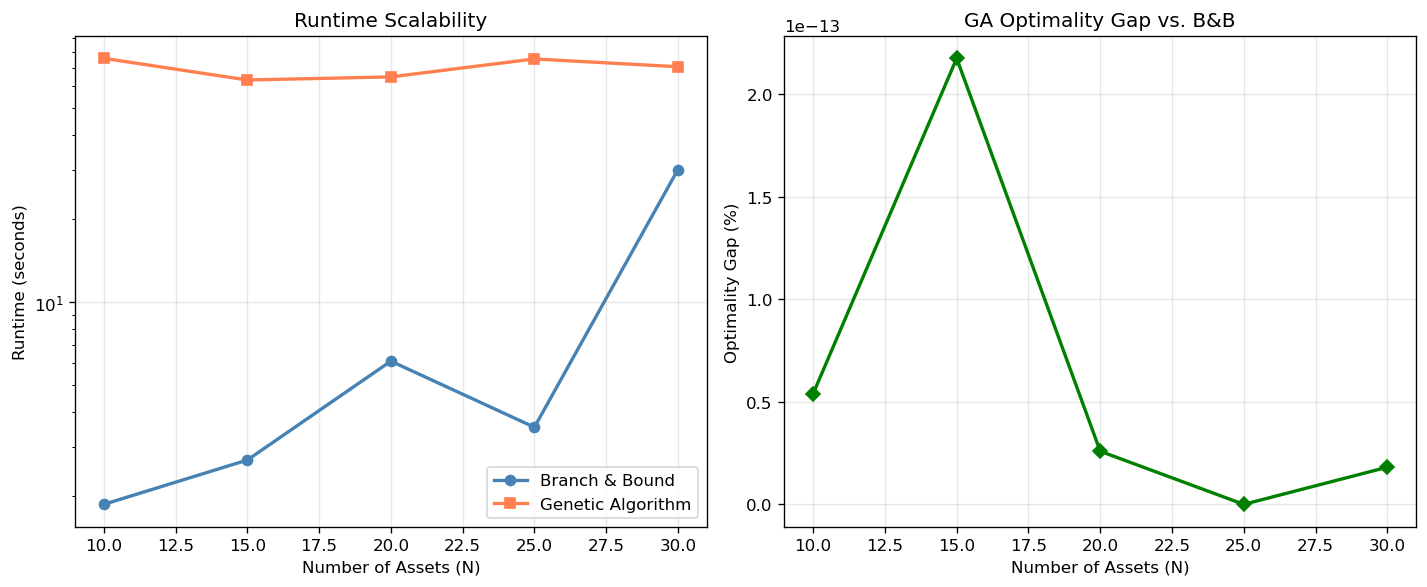

In [29]:
# Scalability plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(scale_df['N'], scale_df['BB_time'], 'o-', lw=2, color='steelblue', label='Branch & Bound')
ax.plot(scale_df['N'], scale_df['GA_time'], 's-', lw=2, color='coral', label='Genetic Algorithm')
ax.set_xlabel('Number of Assets (N)')
ax.set_ylabel('Runtime (seconds)')
ax.set_title('Runtime Scalability')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

ax = axes[1]
ax.plot(scale_df['N'], scale_df['Gap_%'], 'D-', lw=2, color='green')
ax.set_xlabel('Number of Assets (N)')
ax.set_ylabel('Optimality Gap (%)')
ax.set_title('GA Optimality Gap vs. B&B')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_scalability.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# B&B portfolio composition
print("=== B&B PORTFOLIO ===")
bb_selected = np.where(bb_weights > 1e-6)[0]
for i in bb_selected:
    print(f"{asset_names[i]:12s}  {bb_weights[i]*100:.2f}%")

print(f"\nSharpe: {bb_sharpe:.4f}")
print(f"Return: {portfolio_return(bb_weights, mu)*100:.2f}%")
print(f"Volatility: {portfolio_volatility(bb_weights, cov_matrix)*100:.2f}%")

=== B&B PORTFOLIO ===
CFVF          14.20%
SFCL          13.70%
HAYL          6.97%
CTHR          22.15%
GREG          12.21%
GRAN          6.98%
GLAS          13.98%
HUNA          9.82%

Sharpe: 1.8160
Return: 48.66%
Volatility: 21.29%


In [34]:
print("Re-running GA on full CSE dataset...")
ga_weights, ga_sharpe, ga_stats = run_ga_deap(
    mu, cov_matrix, K_MAX, W_MIN, W_MAX,
    pop_size=80, n_generations=150, mutation_rate=0.1
)
print(f"GA Sharpe: {ga_sharpe:.4f}")

Re-running GA on full CSE dataset...
  DEAP GA completed: 150 generations, 480.37s
  Best Sharpe: 1.9072
  Assets selected: 8
GA Sharpe: 1.9072


In [35]:
# Correct comparison table
bb_selected = np.where(bb_weights > 1e-6)[0]
ga_selected = np.where(ga_weights > 1e-6)[0]
all_selected = sorted(set(list(bb_selected) + list(ga_selected)))

print(f"{'Ticker':<14} {'Company':<35} {'B&B Weight':>10} {'GA Weight':>10}")
print("-" * 72)
for i in all_selected:
    bb_w = f"{bb_weights[i]*100:.2f}%" if bb_weights[i] > 1e-6 else "-"
    ga_w = f"{ga_weights[i]*100:.2f}%" if ga_weights[i] > 1e-6 else "-"
    print(f"{asset_names[i]:<14} {asset_sectors[i]:<35} {bb_w:>10} {ga_w:>10}")

print(f"\n{'':14} {'B&B':>45} {'GA':>10}")
print(f"{'Sharpe':<14} {bb_sharpe:>45.4f} {ga_sharpe:>10.4f}")
print(f"{'Return':<14} {portfolio_return(bb_weights,mu)*100:>45.2f}% {portfolio_return(ga_weights,mu)*100:>10.2f}%")
print(f"{'Volatility':<14} {portfolio_volatility(bb_weights,cov_matrix)*100:>45.2f}% {portfolio_volatility(ga_weights,cov_matrix)*100:>10.2f}%")
print(f"{'Assets':<14} {np.sum(bb_weights>1e-6):>45} {np.sum(ga_weights>1e-6):>10}")

Ticker         Company                             B&B Weight  GA Weight
------------------------------------------------------------------------
CFVF           Banking & Finance                       14.20%     11.97%
SFCL           Banking & Finance                       13.70%     10.70%
HAYL           Diversified                              6.97%          -
CTHR           Diversified                             22.15%          -
GREG           Diversified                             12.21%     10.99%
CARG           Food & Beverages                             -     21.09%
GRAN           Food & Beverages                         6.98%          -
LAMB           Food & Beverages                             -     12.07%
GLAS           Manufacturing                           13.98%     12.42%
VLL            Energy                                       -     11.96%
HUNA           Hotels & Travel                          9.82%      8.80%

                                                  